In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import shutil

In [8]:

class CameraTrapDataset(Dataset):
    """
    Loads camera trap frames and prepares them for the model.
    """
    def __init__(self, frames_folder, img_size=256):
        self.frames_folder = frames_folder
        self.img_size = img_size
        
        # get all jpg files sorted by name (preserves time order)
        self.frame_paths = sorted([
            os.path.join(frames_folder, f)
            for f in os.listdir(frames_folder)
            if f.endswith('.jpg')
        ])
        
        print(f"Found {len(self.frame_paths)} frames")
        
        # transforms: resize → tensor → normalise to [-1, 1]
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])
        ])
    
    def __len__(self):
        return len(self.frame_paths)
    
    def __getitem__(self, idx):
        # load image
        img = cv2.imread(self.frame_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # apply transforms
        tensor = self.transform(img)
        
        return tensor, self.frame_paths[idx]  # return path too for tracking


if __name__ == "__main__":
    frames_folder = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/test"
    
    # create dataset
    dataset = CameraTrapDataset(frames_folder, img_size=256)
    print(f"Dataset size: {len(dataset)} frames")
    
    # create dataloader — feeds 8 frames at a time to model
    dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
    
    # test: load first batch and check shape
    frames, paths = next(iter(dataloader))
    print(f"Batch shape: {frames.shape}")  
    # should print: torch.Size([8, 3, 256, 256])
    # meaning: 8 frames, 3 colour channels, 256x256 pixels
    
    print(f"Pixel value range: {frames.min():.2f} to {frames.max():.2f}")
    # should print: -1.00 to 1.00 (normalised)
    
    print("\nFirst 3 frame paths:")
    for p in paths[:3]:
        print(f"  {os.path.basename(p)}")

Found 2160 frames
Dataset size: 2160 frames
Batch shape: torch.Size([8, 3, 256, 256])
Pixel value range: -1.00 to 1.00

First 3 frame paths:
  frame_00000.jpg
  frame_00001.jpg
  frame_00002.jpg


### Basedline method - autoencoder

In [9]:
class Encoder(nn.Module):
    """Compresses a frame down to a small vector."""
    def __init__(self, latent_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            # 3x256x256 → 64x128x128
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # 64x128x128 → 128x64x64
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 128x64x64 → 256x32x32
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # 256x32x32 → 512x16x16
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            # flatten → latent vector
            nn.Flatten(),
            nn.Linear(512 * 16 * 16, latent_dim)
        )

    def forward(self, x):
        return self.encoder(x)


class Decoder(nn.Module):
    """Reconstructs a frame from a small vector."""
    def __init__(self, latent_dim=512):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 16 * 16)
        self.decoder = nn.Sequential(
            # 512x16x16 → 256x32x32
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # 256x32x32 → 128x64x64
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 128x64x64 → 64x128x128
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # 64x128x128 → 3x256x256
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # output range [-1, 1] matches our normalisation
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 16, 16)
        return self.decoder(x)


class Autoencoder(nn.Module):
    """Full autoencoder = encoder + decoder."""
    def __init__(self, latent_dim=512):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

    def anomaly_score(self, x):
        """Higher score = more anomalous."""
        reconstructed = self.forward(x)
        # mean squared error per frame
        error = torch.mean((x - reconstructed) ** 2, dim=[1, 2, 3])
        return error


if __name__ == "__main__":
    # test the model with a dummy batch
    model = Autoencoder(latent_dim=512)
    
    # fake batch of 4 frames at 256x256
    dummy_input = torch.randn(4, 3, 256, 256)
    
    output = model(dummy_input)
    scores = model.anomaly_score(dummy_input)
    
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Anomaly scores: {scores}")
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

Input shape:  torch.Size([4, 3, 256, 256])
Output shape: torch.Size([4, 3, 256, 256])
Anomaly scores: tensor([1.3678, 1.3739, 1.3540, 1.3734], grad_fn=<MeanBackward1>)

Model parameters: 139,864,579


In [ ]:
# ── config ────────────────────────────────────────────────
FRAMES_FOLDER = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/test"
OUTPUT_FOLDER = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs"
IMG_SIZE      = 256
BATCH_SIZE    = 8
EPOCHS        = 30
LEARNING_RATE = 0.001
LATENT_DIM    = 512
# ─────────────────────────────────────────────────────────

def train():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # ── 1. load data ──────────────────────────────────────
    print("Loading dataset...")
    dataset    = CameraTrapDataset(FRAMES_FOLDER, img_size=IMG_SIZE)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"Training on {len(dataset)} frames")

    # ── 2. set up model ───────────────────────────────────
    device = torch.device("mps"  if torch.backends.mps.is_available()  else
                          "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model     = Autoencoder(latent_dim=LATENT_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    # ── 3. training loop ──────────────────────────────────
    losses = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0

        for frames, _ in dataloader:
            frames = frames.to(device)
            optimizer.zero_grad()
            reconstructed = model(frames)
            loss = criterion(reconstructed, frames)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(dataloader)
        losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss: {epoch_loss:.4f}")

        # save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(OUTPUT_FOLDER, f"model_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  → checkpoint saved: model_epoch{epoch+1}.pth")

    # save model
    torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, "model.pth"))
    print(f"\nModel saved to {OUTPUT_FOLDER}/model.pth")

    # plot loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training loss")
    plt.savefig(os.path.join(OUTPUT_FOLDER, "loss_curve.png"))
    print(f"Loss curve saved")

    return model, device


def detect_anomalies(model, device):
    """
    Score every frame — high score = potential anomaly = hummingbird candidate.
    """
    print("\nScoring all frames for anomalies...")

    dataset    = CameraTrapDataset(FRAMES_FOLDER, img_size=IMG_SIZE)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    all_scores = []
    all_paths  = []

    model.eval()
    with torch.no_grad():
        for frames, paths in dataloader:
            frames = frames.to(device)
            scores = model.anomaly_score(frames)
            all_scores.extend(scores.cpu().numpy())
            all_paths.extend(paths)

    # sort by score — highest first
    ranked = sorted(zip(all_scores, all_paths), reverse=True)

    # print top 10 most anomalous frames
    print("\nTop 10 most anomalous frames:")
    print("-" * 50)
    for score, path in ranked[:10]:
        print(f"  score: {score:.4f}  →  {os.path.basename(path)}")

    # plot anomaly score distribution
    plt.figure(figsize=(10, 4))
    plt.plot([s for s, _ in ranked])
    plt.xlabel("Frame rank")
    plt.ylabel("Anomaly score")
    plt.title("Anomaly scores — spike = potential hummingbird")
    plt.savefig(os.path.join(OUTPUT_FOLDER, "anomaly_scores.png"))
    print(f"\nAnomaly score plot saved to {OUTPUT_FOLDER}/anomaly_scores.png")

    # save top 20 suspicious frames to review manually
    suspicious_folder = os.path.join(OUTPUT_FOLDER, "suspicious_frames")
    os.makedirs(suspicious_folder, exist_ok=True)

    import shutil
    for i, (score, path) in enumerate(ranked[:20]):
        dest = os.path.join(suspicious_folder, f"rank{i+1:02d}_score{score:.4f}_{os.path.basename(path)}")
        shutil.copy(path, dest)

    print(f"Top 20 suspicious frames copied to {suspicious_folder}")
    print("\nOpen that folder and visually check if any contain hummingbirds!")


if __name__ == "__main__":
    model, device = train()
    detect_anomalies(model, device)

Loading dataset...
Found 2160 frames
Training on 2160 frames
Using device: mps
Epoch [1/30]  Loss: 0.0949
Epoch [2/30]  Loss: 0.0378
Epoch [3/30]  Loss: 0.0267
Epoch [4/30]  Loss: 0.0203
Epoch [5/30]  Loss: 0.0162
Epoch [6/30]  Loss: 0.0145
Epoch [7/30]  Loss: 0.0129
Epoch [8/30]  Loss: 0.0118
Epoch [9/30]  Loss: 0.0105
Epoch [10/30]  Loss: 0.0099
Epoch [11/30]  Loss: 0.0091
Epoch [12/30]  Loss: 0.0091
Epoch [13/30]  Loss: 0.0079
Epoch [14/30]  Loss: 0.0080
Epoch [15/30]  Loss: 0.0075
Epoch [16/30]  Loss: 0.0079
Epoch [17/30]  Loss: 0.0066
Epoch [18/30]  Loss: 0.0065
Epoch [19/30]  Loss: 0.0065
Epoch [20/30]  Loss: 0.0063
Epoch [21/30]  Loss: 0.0066
Epoch [22/30]  Loss: 0.0056
Epoch [23/30]  Loss: 0.0057
Epoch [24/30]  Loss: 0.0055
Epoch [25/30]  Loss: 0.0054
Epoch [26/30]  Loss: 0.0051
Epoch [27/30]  Loss: 0.0053
Epoch [28/30]  Loss: 0.0049
Epoch [29/30]  Loss: 0.0046
Epoch [30/30]  Loss: 0.0046

Model saved to /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/model.pth


NameError: name 'plt' is not defined

Using device: mps
Model loaded successfully
Found 2160 frames
Scoring 2160 frames in time order...
  scored 400/2160 frames...
  scored 800/2160 frames...
  scored 1200/2160 frames...
  scored 1600/2160 frames...
  scored 2000/2160 frames...

Score statistics:
  Total frames : 2160
  Mean score   : 0.0052
  Std          : 0.0030
  Max score    : 0.0246
  Min score    : 0.0011
  Threshold    : 0.0111  (mean + 2×std)
  Flagged      : 95 / 2160 frames above threshold

Plot saved to /Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/anomaly_scores.png

Top 20 most anomalous frames:
------------------------------------------------------------
  rank 01: score 0.0246  frame_00554.jpg  ← ABOVE THRESHOLD
  rank 02: score 0.0242  frame_00541.jpg  ← ABOVE THRESHOLD
  rank 03: score 0.0235  frame_00512.jpg  ← ABOVE THRESHOLD
  rank 04: score 0.0229  frame_00562.jpg  ← ABOVE THRESHOLD
  rank 05: score 0.0229  frame_00553.jpg  ← ABOVE THRESHOLD
  rank 06: score 0.0224  frame_00542.jpg  ← A

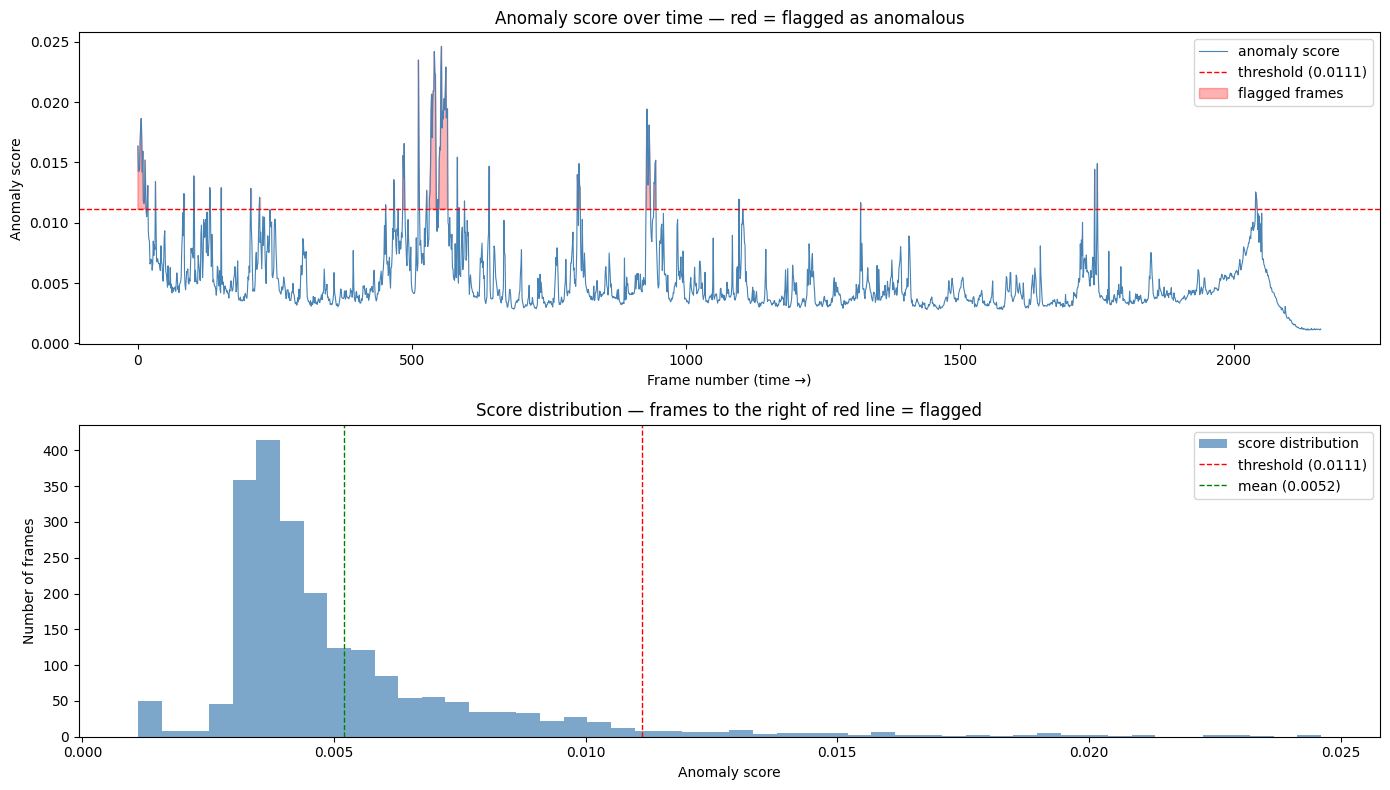

In [11]:
import torch
import os
import numpy as np
import shutil
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── config ────────────────────────────────────────────────
FRAMES_FOLDER = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/data/frames/test"
OUTPUT_FOLDER = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs"
MODEL_PATH    = "/Users/iris/Desktop/ETH/DAS Project/camera-trap-gan/outputs/model.pth"
IMG_SIZE      = 256
BATCH_SIZE    = 8
LATENT_DIM    = 512
TOP_N         = 20       # how many suspicious frames to save
THRESHOLD_STD = 2        # mean + 2×std threshold
# ─────────────────────────────────────────────────────────

def detect():
    # ── 1. load model ─────────────────────────────────────
    device = torch.device("mps"  if torch.backends.mps.is_available() else
                          "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = Autoencoder(latent_dim=LATENT_DIM).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded successfully")

    # ── 2. score every frame in time order ────────────────
    dataset    = CameraTrapDataset(FRAMES_FOLDER, img_size=IMG_SIZE)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    print(f"Scoring {len(dataset)} frames in time order...")

    all_scores = []
    all_paths  = []

    with torch.no_grad():
        for i, (frames, paths) in enumerate(dataloader):
            frames = frames.to(device)
            scores = model.anomaly_score(frames)
            all_scores.extend(scores.cpu().numpy())
            all_paths.extend(paths)
            if (i + 1) % 50 == 0:
                print(f"  scored {(i+1)*BATCH_SIZE}/{len(dataset)} frames...")

    scores_np = np.array(all_scores)

    # ── 3. print statistics ───────────────────────────────
    mean      = scores_np.mean()
    std       = scores_np.std()
    threshold = mean + THRESHOLD_STD * std

    print(f"\nScore statistics:")
    print(f"  Total frames : {len(scores_np)}")
    print(f"  Mean score   : {mean:.4f}")
    print(f"  Std          : {std:.4f}")
    print(f"  Max score    : {scores_np.max():.4f}")
    print(f"  Min score    : {scores_np.min():.4f}")
    print(f"  Threshold    : {threshold:.4f}  (mean + {THRESHOLD_STD}×std)")

    flagged = [(s, p) for s, p in zip(all_scores, all_paths) if s > threshold]
    print(f"  Flagged      : {len(flagged)} / {len(scores_np)} frames above threshold")

    # ── 4. plot scores over time ──────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

    # top plot: scores over time
    ax1.plot(scores_np, linewidth=0.8, color='steelblue', label='anomaly score')
    ax1.axhline(y=threshold, color='red', linestyle='--',
                linewidth=1, label=f'threshold ({threshold:.4f})')
    ax1.fill_between(range(len(scores_np)), scores_np, threshold,
                     where=scores_np > threshold,
                     color='red', alpha=0.3, label='flagged frames')
    ax1.set_xlabel("Frame number (time →)")
    ax1.set_ylabel("Anomaly score")
    ax1.set_title("Anomaly score over time — red = flagged as anomalous")
    ax1.legend()

    # bottom plot: score distribution histogram
    ax2.hist(scores_np, bins=50, color='steelblue', alpha=0.7, label='score distribution')
    ax2.axvline(x=threshold, color='red', linestyle='--',
                linewidth=1, label=f'threshold ({threshold:.4f})')
    ax2.axvline(x=mean, color='green', linestyle='--',
                linewidth=1, label=f'mean ({mean:.4f})')
    ax2.set_xlabel("Anomaly score")
    ax2.set_ylabel("Number of frames")
    ax2.set_title("Score distribution — frames to the right of red line = flagged")
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_FOLDER, "anomaly_scores.png")
    plt.savefig(plot_path)
    print(f"\nPlot saved to {plot_path}")

    # ── 5. print top 20 most anomalous ────────────────────
    ranked = sorted(zip(all_scores, all_paths), reverse=True)
    print(f"\nTop {TOP_N} most anomalous frames:")
    print("-" * 60)
    for i, (score, path) in enumerate(ranked[:TOP_N]):
        flag = "← ABOVE THRESHOLD" if score > threshold else ""
        print(f"  rank {i+1:02d}: score {score:.4f}  {os.path.basename(path)}  {flag}")

    # ── 6. save top 20 suspicious frames ──────────────────
    suspicious_folder = os.path.join(OUTPUT_FOLDER, "suspicious_frames")
    os.makedirs(suspicious_folder, exist_ok=True)

    # clear old results
    for f in os.listdir(suspicious_folder):
        os.remove(os.path.join(suspicious_folder, f))

    for i, (score, path) in enumerate(ranked[:TOP_N]):
        dest = os.path.join(
            suspicious_folder,
            f"rank{i+1:02d}_score{score:.4f}_{os.path.basename(path)}"
        )
        shutil.copy(path, dest)

    print(f"\nTop {TOP_N} frames saved to suspicious_frames/")
    print("Opening output folder...")
    os.system(f"open '{OUTPUT_FOLDER}'")


if __name__ == "__main__":
    detect()